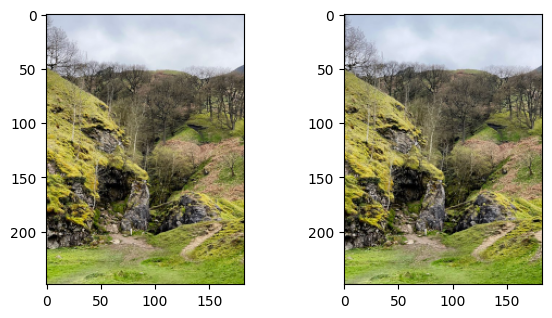

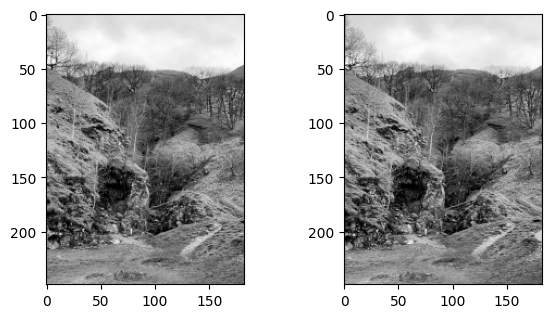

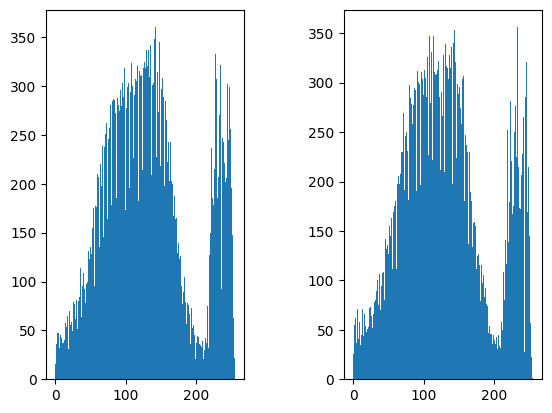

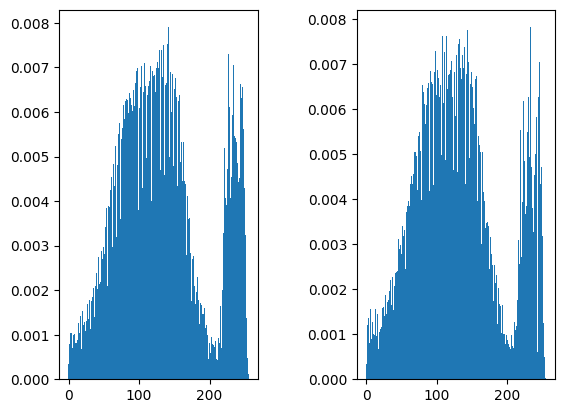

In [74]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np

# the path of the images to be analyzed
l_path = "l_183x249.png"
r_path = "r_183x249.png"
paths = [l_path, r_path]

# load images and show
imgs = [mpimg.imread(x) for x in paths]

fig, axes = plt.subplots(1, len(imgs))
[axes[i].imshow(x) for i, x in enumerate(imgs)]
fig.subplots_adjust(wspace=0.5)
plt.show()

# prepare images
for i in range(len(imgs)):
    img = imgs[i]

    if img.ndim == 3:
        img = img.mean(axis=2)

    normalized = (img - img.min()) / (img.max() - img.min()) * 255
    normalized = normalized.astype(np.uint8)

    imgs[i] = normalized

# plot prepared images and histogram
fig, axes = plt.subplots(1, len(imgs))
[axes[i].imshow(x, cmap="gray") for i, x in enumerate(imgs)]
fig.subplots_adjust(wspace=0.5)
plt.show()

# histogram
hist = [np.bincount(x.ravel(), minlength=256) for x in imgs]

fig, axes = plt.subplots(1, len(imgs))
[axes[i].bar(np.arange(256), x, width=1) for i, x in enumerate(hist)]
fig.subplots_adjust(wspace=0.5)
plt.show()

# calculate probabilities
p = [hist[i]/(img.shape[0] * img.shape[1]) for i, x in enumerate(imgs)]

fig, axes = plt.subplots(1, len(imgs))
[axes[i].bar(np.arange(256), x, width=1) for i, x in enumerate(p)]
fig.subplots_adjust(wspace=0.5)
plt.show()